C:\Users\abhis\AppData\Local\Temp\ipykernel_27820\462169885.py:15: DtypeWarning: Columns (0,1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


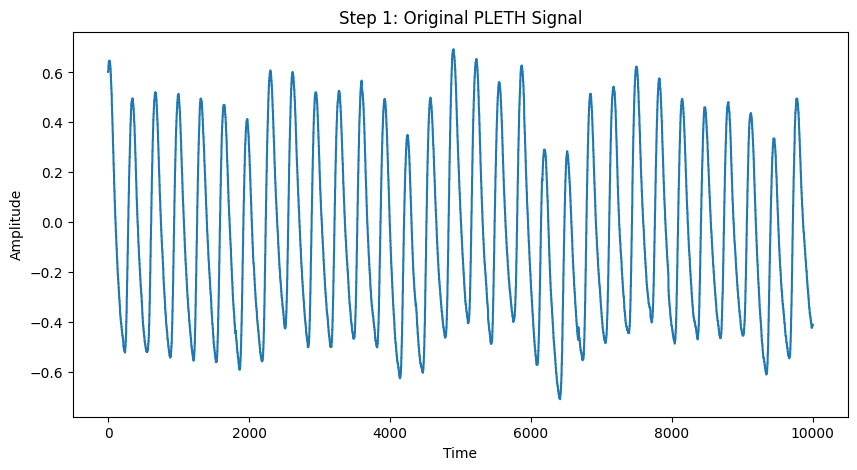

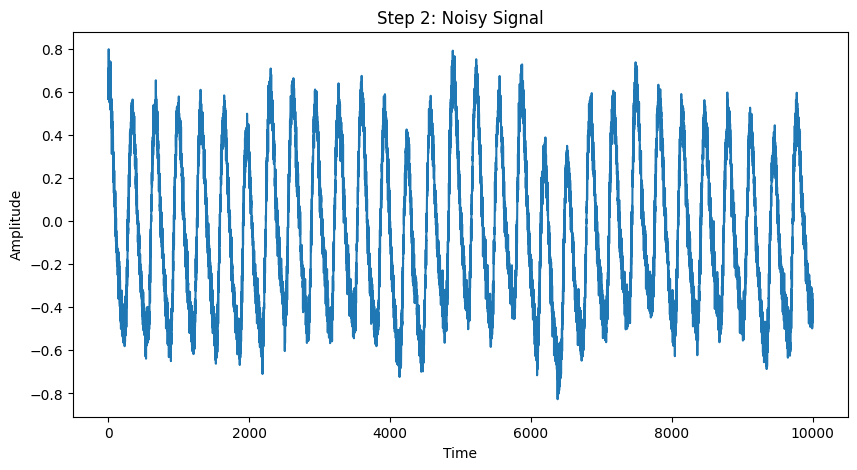

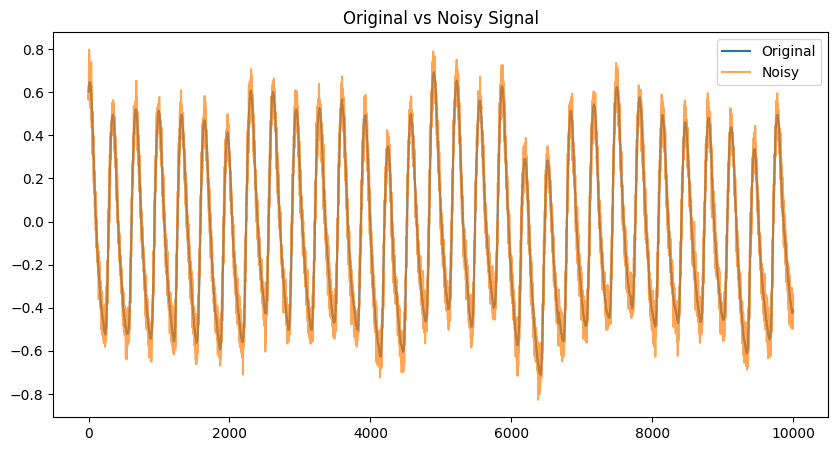

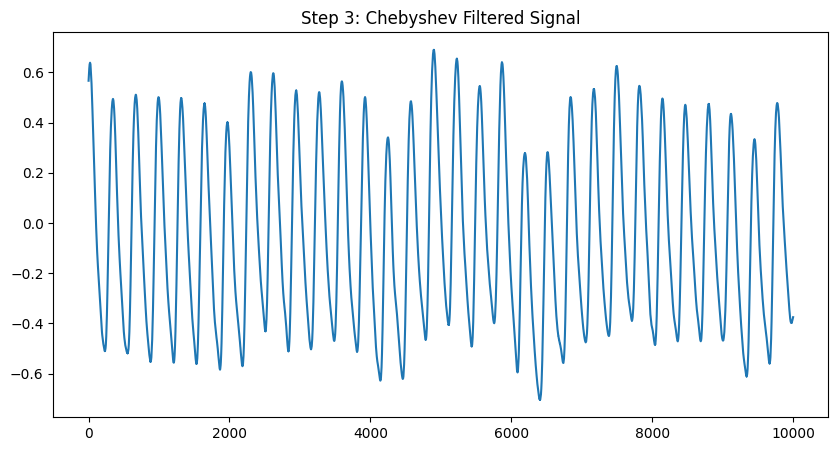

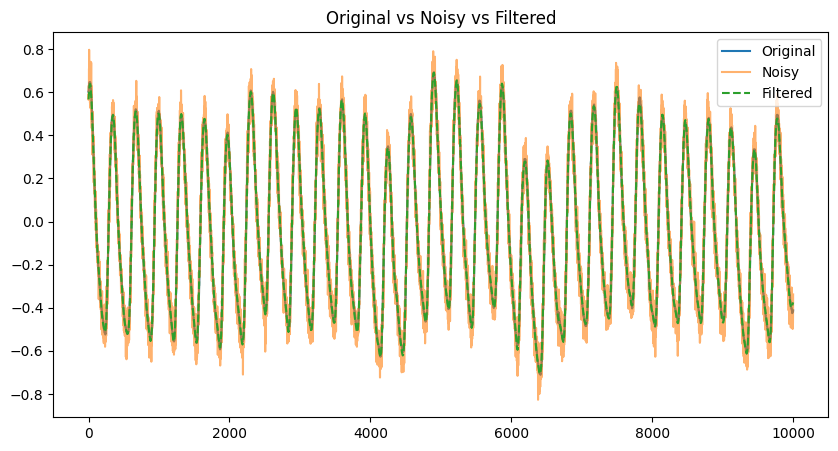

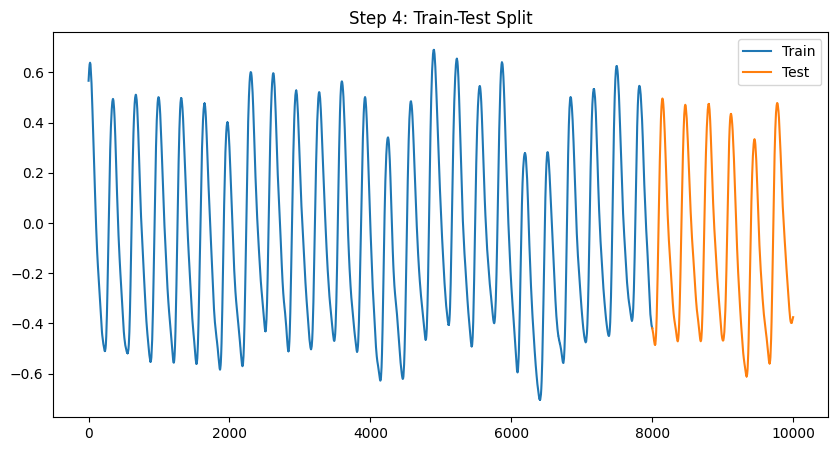

Epoch 1/10


c:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0958 - mae: 0.2602 - val_loss: 0.0026 - val_mae: 0.0405
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0039 - mae: 0.0494 - val_loss: 0.0024 - val_mae: 0.0391
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0039 - mae: 0.0488 - val_loss: 0.0025 - val_mae: 0.0396
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039 - mae: 0.0495 - val_loss: 0.0024 - val_mae: 0.0394
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - mae: 0.0489 - val_loss: 0.0024 - val_mae: 0.0391
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - mae: 0.0489 - val_loss: 0.0024 - val_mae: 0.0391
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0037 - mae: 0.0480 - val_loss: 0.0024 - val_mae: 0.0390
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - mae: 0.0478 - val_loss: 0.0025 - val_mae: 0.0402
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 

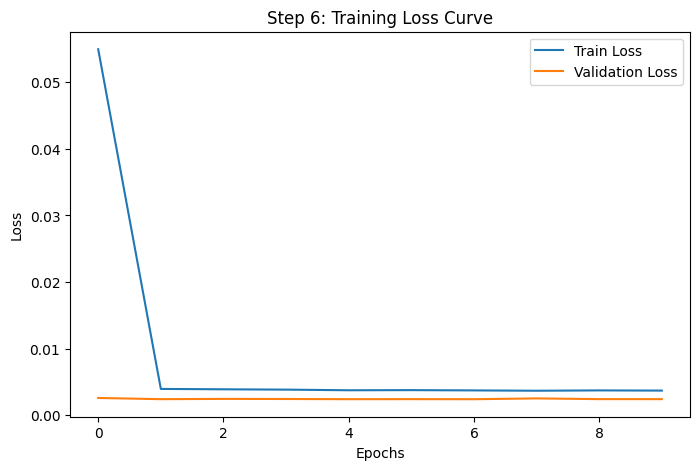

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


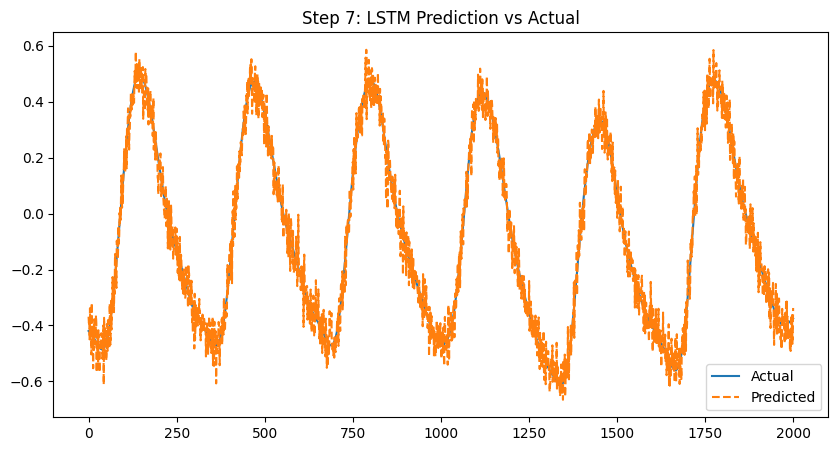

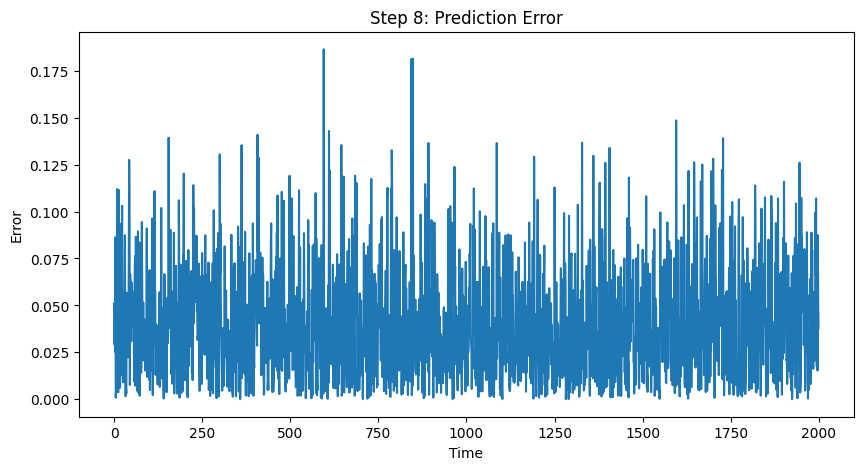

MSE: 0.002420385557168547
MAE: 0.03911087176202867


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import cheby2, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =========================
# 1. LOAD DATASET
# =========================
file_path = "samples2.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip().str.replace("'", "").str.replace(" ", "")
df = df.apply(pd.to_numeric, errors='coerce').dropna()
df = df.iloc[:10000]

pleth_signal = df["PLETH"].values

# 🔹 Graph 1: Original Signal
plt.figure(figsize=(10,5))
plt.plot(pleth_signal)
plt.title("Step 1: Original PLETH Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

# =========================
# 2. ADD NOISE
# =========================
noise_std = 0.05
noisy_signal = pleth_signal + np.random.normal(0, noise_std, size=pleth_signal.shape)

# 🔹 Graph 2: Noisy Signal
plt.figure(figsize=(10,5))
plt.plot(noisy_signal)
plt.title("Step 2: Noisy Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

# 🔹 Graph 3: Original vs Noisy
plt.figure(figsize=(10,5))
plt.plot(pleth_signal, label="Original")
plt.plot(noisy_signal, label="Noisy", alpha=0.7)
plt.legend()
plt.title("Original vs Noisy Signal")
plt.show()

# =========================
# 3. CHEBYSHEV FILTER
# =========================
def chebyshev_filter(data, cutoff=2, fs=100, order=4, rs=20):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = cheby2(order, rs, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

filtered_signal = chebyshev_filter(noisy_signal)

# 🔹 Graph 4: Filtered Signal
plt.figure(figsize=(10,5))
plt.plot(filtered_signal)
plt.title("Step 3: Chebyshev Filtered Signal")
plt.show()

# 🔹 Graph 5: All Comparison
plt.figure(figsize=(10,5))
plt.plot(pleth_signal, label="Original")
plt.plot(noisy_signal, label="Noisy", alpha=0.6)
plt.plot(filtered_signal, label="Filtered", linestyle="dashed")
plt.legend()
plt.title("Original vs Noisy vs Filtered")
plt.show()

# =========================
# 4. PREPARE DATA FOR LSTM
# =========================
X = noisy_signal.reshape(-1, 1, 1)
y = filtered_signal.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 🔹 Graph 6: Train-Test Split
plt.figure(figsize=(10,5))
plt.plot(y_train, label="Train")
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test, label="Test")
plt.legend()
plt.title("Step 4: Train-Test Split")
plt.show()

# =========================
# 5. BUILD LSTM MODEL
# =========================
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(1,1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# =========================
# 6. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

# 🔹 Graph 7: Training Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Step 6: Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# =========================
# 7. PREDICTION
# =========================
y_pred = model.predict(X_test)

# 🔹 Graph 8: Prediction vs Actual
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted", linestyle='dashed')
plt.legend()
plt.title("Step 7: LSTM Prediction vs Actual")
plt.show()

# =========================
# 8. ERROR ANALYSIS
# =========================
error = np.abs(y_test - y_pred)

# 🔹 Graph 9: Error Plot
plt.figure(figsize=(10,5))
plt.plot(error)
plt.title("Step 8: Prediction Error")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

# =========================
# 9. METRICS
# =========================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")